**LIBRARIES**

In [6]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [7]:
class Beale:
    def __init__(self):
        self.name   = "Beale"
        self.minima = [(3, 0.5)]
        self.limits = [(-4, 4), (-4, 4)]

    def evaluate(self, x, y):
        return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2

In [8]:
def lectura(filepath: str):
    # 1. Cargar datos 
    # Leemos el archivo detectando automáticamente el separador (puede ser coma, punto y coma, tabulación, etc.)
    df = pd.read_csv(filepath, sep=None, engine='python')

    # Limpiamos nombres de columnas (quita espacios invisibles como " X" -> "X")
    df.columns = df.columns.str.strip()
    print(f"Columnas detectadas: {list(df.columns)}")

    # 3. Extraer valores de la columna 2 (X) y de la columna 3(Y) (Usando .iloc es más seguro si las columnas son la 2 y la 3)
    val_x = df.iloc[:, 1] # iloc[:, 1] es la segunda columna donde estan los valores de X
    val_y = df.iloc[:, 2] # iloc[:, 2] es la tercera columna donde estan los valores de Y

    return val_x, val_y, df

In [9]:
def plot_beale(val_x, val_y, round: str): #, save_figure: bool = False): 

    function = Beale()

    ###-PLOT-###
    # 1. Crear el fondo de la función
    x_range = np.linspace(-4, 4, 400)
    y_range = np.linspace(-4, 4, 400)
    X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
    Z_mesh = function.evaluate(X_mesh, Y_mesh)

    # 2. Dibujar el mapa
    plt.figure(figsize=(10, 7))
    plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-2, 5, 40), norm=LogNorm(), cmap='viridis', alpha=0.7)
    plt.colorbar(label='Beale value')

    # 3. Dibujar TUS puntos (usando el df que ya tienes en memoria)
    plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Explored points')

    # Añadir etiquetas de número de RUN
    #for i, row in df.iterrows():
    #    plt.text(row.iloc[1]+0.1, row.iloc[2]+0.1, str(int(row.iloc[0])), color='white', fontsize=9)

    plt.title(f"Round {round}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()

    return plt

In [4]:
save_plot = False

------------------------------
Procesando archivo: Beale_R0.csv
Guardando Output en Beale_R0_RESULTADO.csv
Guardando Gráfico en Beale_R0_plot.jpg
Round: 0
------------------------------
Columnas detectadas: ['Run', 'X', 'Y']
   Run     X        Y            R0
0    1  0.64 -0.52000      7.048295
1    2 -2.72 -4.00000  33907.443125
2    3  0.64 -4.00000   1662.363125
3    4  4.00  3.00000  12632.203125
4    5  1.20  2.31926    334.631802
------------------------------
Procesando archivo: Beale_R1.csv
Guardando Output en Beale_R1_RESULTADO.csv
Guardando Gráfico en Beale_R1_plot.jpg
Round: 1
------------------------------
Columnas detectadas: ['Number', 'X', 'Y', 'R1']
   Number      X      Y           R1           R0
0       1  2.098  1.097  -800772.689    20.934856
1       2  1.200  3.360  -362074.718  2435.655593
2       3  1.200  2.319 -1263775.695   334.443113
3       4 -2.160 -1.200 -1375990.715   113.323930
4       5 -2.720 -1.600  -903222.524   349.244183
-------------------------

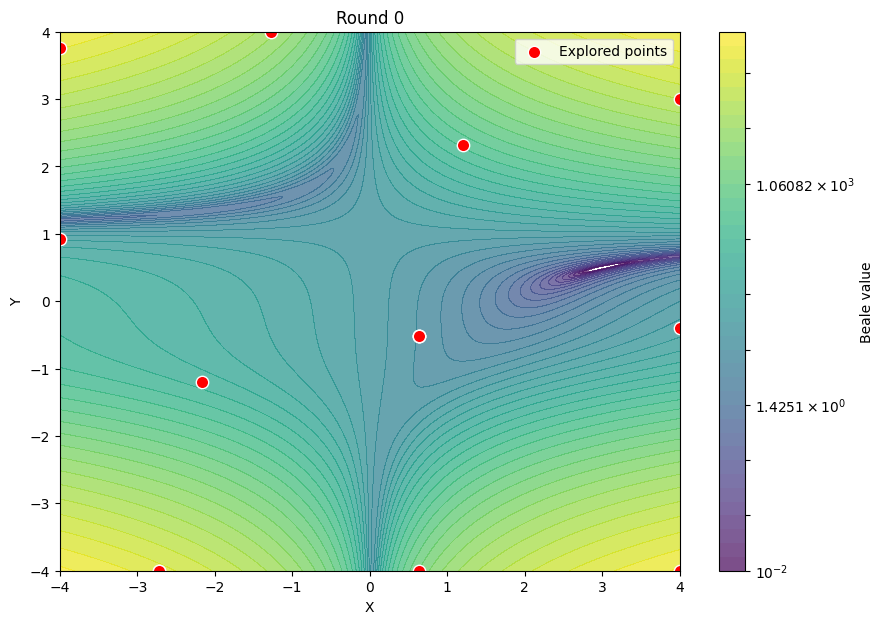

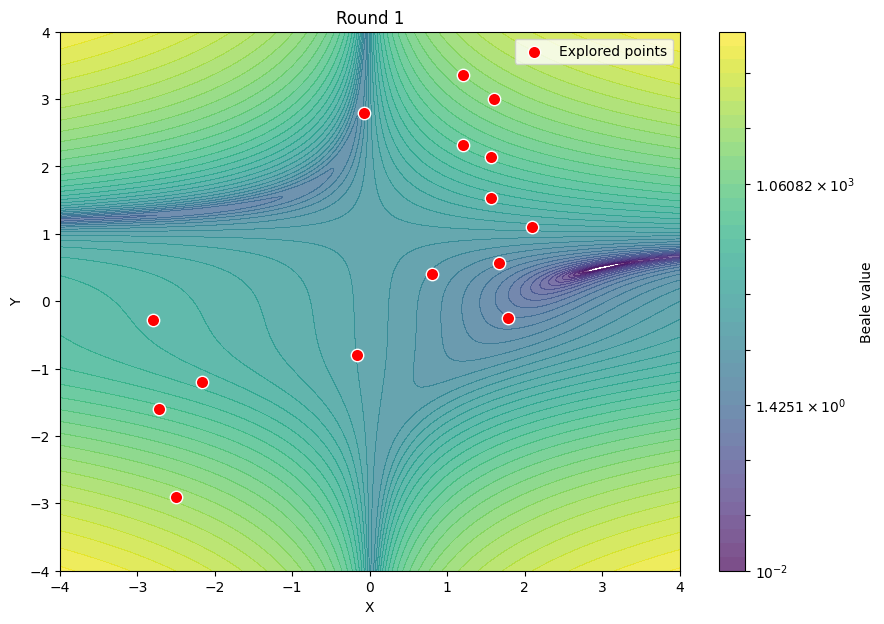

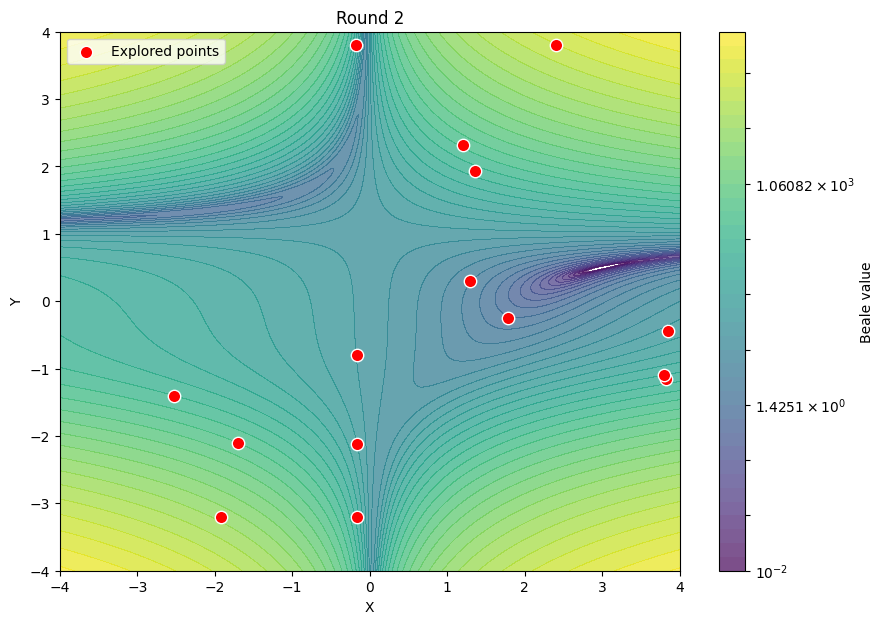

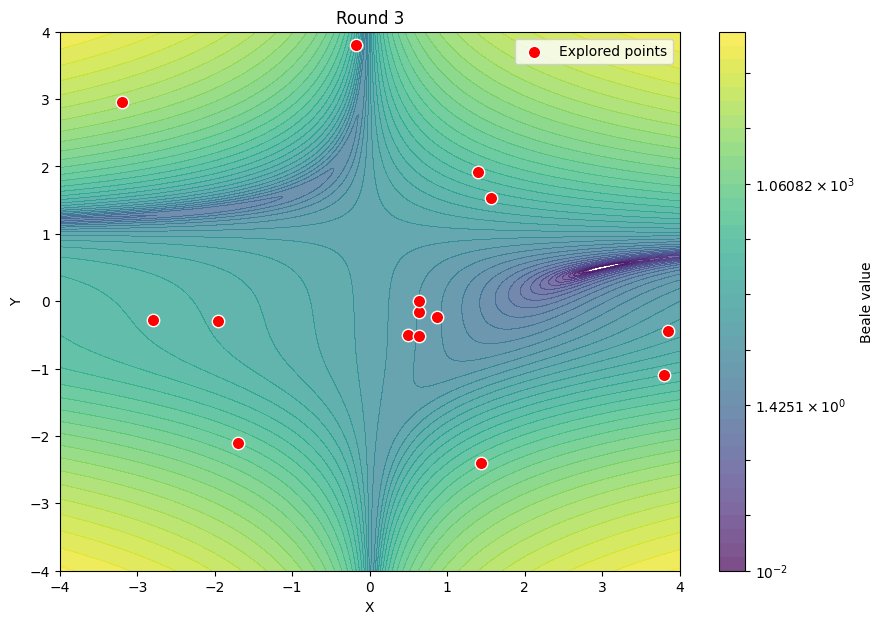

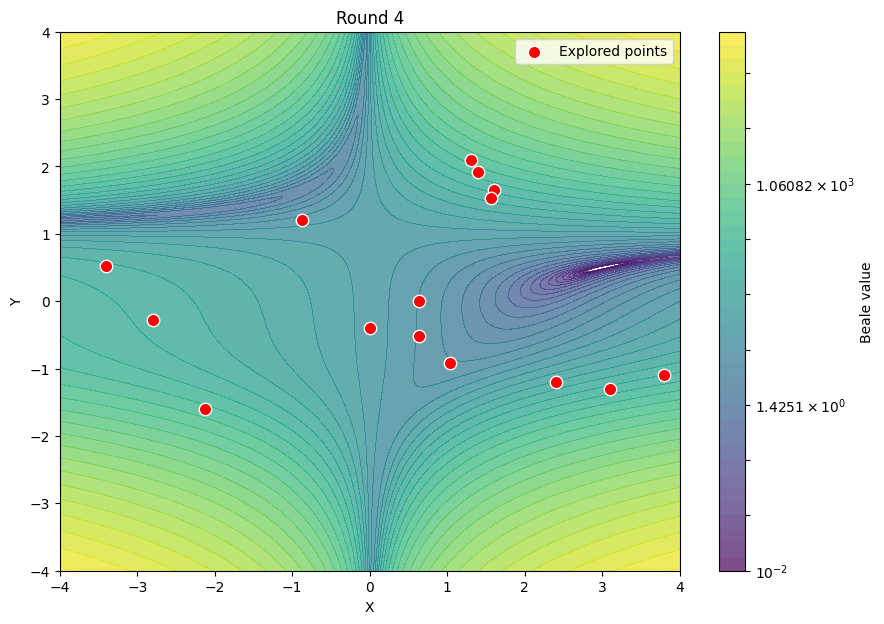

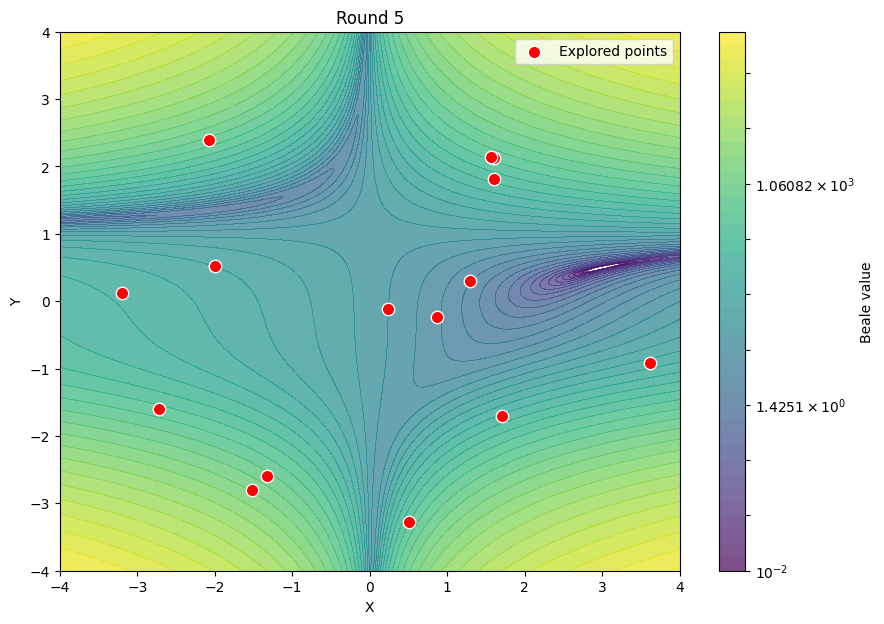

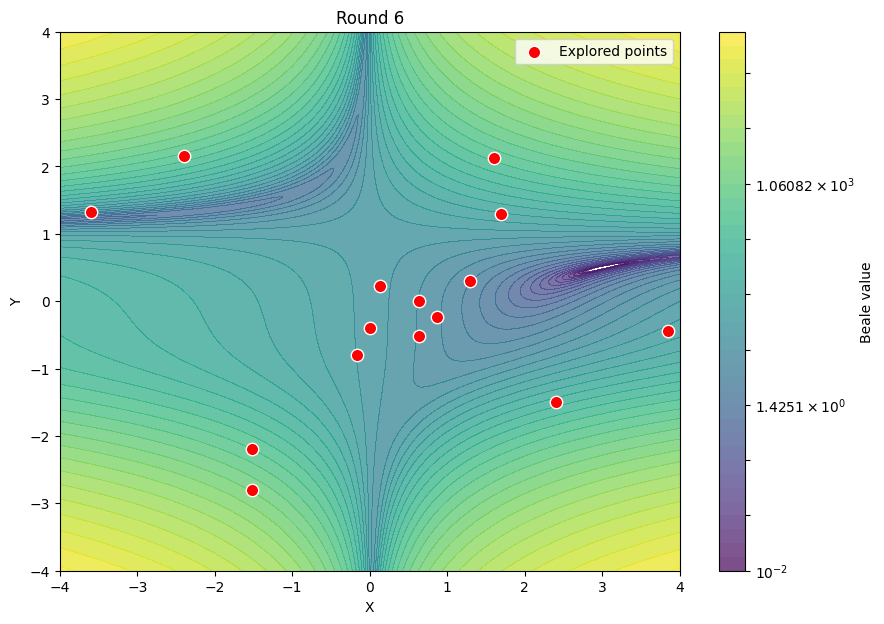

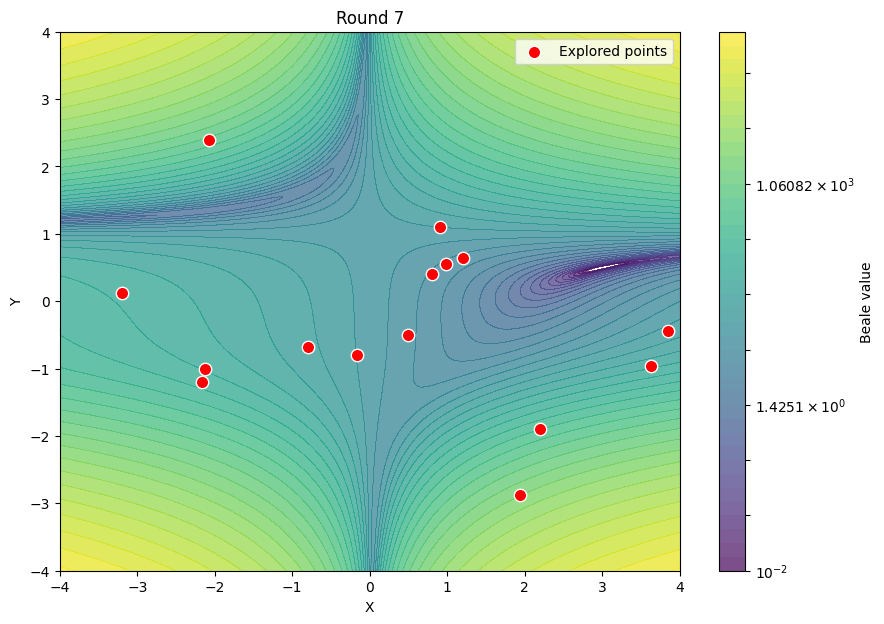

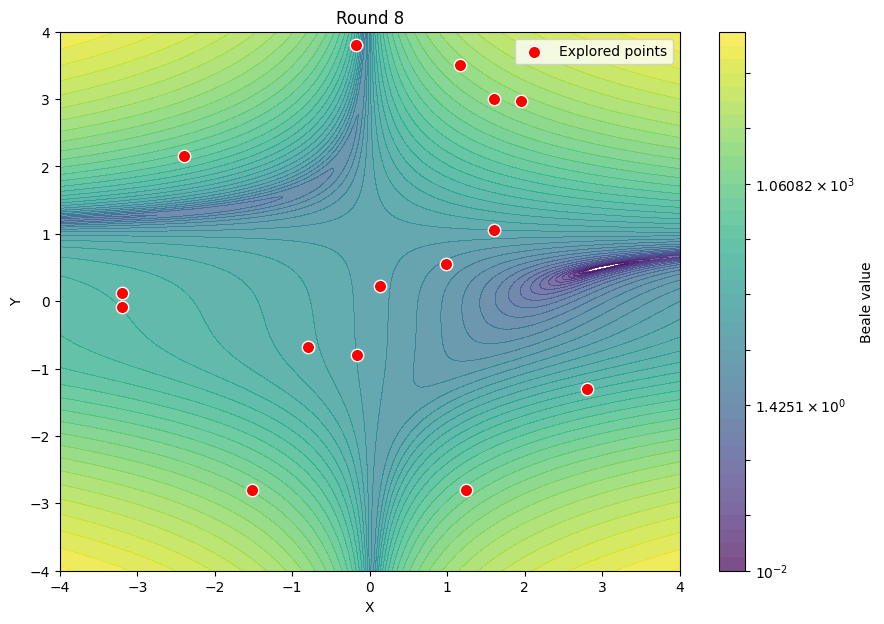

In [10]:
function = Beale()
csvs = [f for f in os.listdir("C:\\Users\\Usuario\\Documents\\TFM-MELINA\\Beale") if f.endswith('.csv') and f.startswith('Beale') and "RESULTADO" not in f and "plot" not in f]

for file in csvs:
    output_file = file.replace('.csv', '_RESULTADO.csv')
    plot_file   = file.replace('.csv', '_plot.jpg')
    round       = int(file.split('_')[-1].replace('.csv', '').replace('R', '')) # Extrae el número de round del nombre del archivo

    print("-" * 30)
    print(f"Procesando archivo: {file}")
    print(f"Guardando Output en {output_file}")
    print(f"Guardando Gráfico en {plot_file}")
    print(f"Round: {round}")
    print("-" * 30)

    val_x, val_y, df = lectura(file)

    # 4. Calcular el resultado y gua1rdarlo en la nueva columna 4 (indice 3)
    df['R0'] = function.evaluate(val_x, val_y)

    # 5. Guardar el archivo actualizado en el Escritorio
    df.to_csv(output_file, index=False)

    print(df.head()) # Mostrar los primeros resultados para verificar
    plt = plot_beale(val_x, val_y, str(round))
    
    if save_plot:
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        print(f"Gráfico guardado correctamente como :{plot_file}")



**MAE + DISTANCE VALUES**

In [13]:

folder_path = r"C:\Users\Usuario\Documents\TFM-MELINA\Beale"
csvs2 = [f for f in os.listdir(folder_path) if f.endswith('RESULTADO.csv') and f.startswith('Beale')]

resum_csv = []

for file in csvs2:
    file_path = os.path.join(folder_path, file)

    val_x, val_y, df = lectura(file_path) ## llegim les dades

    val_real = function.evaluate(val_x, val_y) ## calcul del valor REAl de la funcio per a cada punt

# 3. DISTÀNCIES: Calculem la distància de cada punt al mínim global de la funció (3, 0.5) i guardem aquestes distàncies en noves columnes al DataFrame
    for i, (mx, my) in enumerate(function.minima, 1):
        df[f'M{i}'] = np.sqrt((val_x - mx)**2 + (val_y - my)**2)

    # 4. MAE: Calculem l'error punt a punt i fem la mitjana final
    if 'R1' in df.columns:
        df['Error_Puntual'] = np.abs(df['R1'] - val_real)
        mae_final = df['Error_Puntual'].mean()
    else:
        mae_final = 0 # Per si és la R0 i no hi ha predicció encara

    # 5. RESULTATS
    # Extraiem el número de ronda del nom del fitxer per al print
    ronda_nom = file.split('_')[1] 
    
    
 # --- 2. EN EL DICCIONARI ES GUARDA SOLS UNA DISTÀNCIA AL MÍNIM GLOBAL ---
    fila_resum = {
        'ROUNDS': ronda_nom,
        'MAE': mae_final,
        'Distance': df['M1'].min() # La distància mínima al mínim global (3, 0.5) que has calculat a la columna M1
    }
    
    # Afegim la fila a la nostra llista
    resum_csv.append(fila_resum)
    
    # Mantenim els teus prints per veure-ho per pantalla
    print(f"Processada {ronda_nom} - MAE: {mae_final:.4f}")

# --- 3. CREAR EL CSV FINAL AMB TOTS ELS RESULTATS ---
if resum_csv:
    df_final = pd.DataFrame(resum_csv)
    
    # Opcional: Ordenar les rondes numèricament perquè el gràfic no surti desordenat
    df_final['n'] = df_final['ROUNDS'].str.extract('(\d+)').astype(int)
    df_final = df_final.sort_values('n').drop(columns=['n'])
    
    # Guardem el fitxer que llegirà el codi del gràfic
    ruta_sortida = os.path.join(folder_path, "Summary_Table_Beale.csv")
    df_final.to_csv(ruta_sortida, index=False)
    
    print("\n" + "="*40)
    print(f"Fitxer guardat correctament a:\n{ruta_sortida}")
    print("="*40)
    print(df_final.to_string(index=False))

Columnas detectadas: ['Run', 'X', 'Y', 'R0']
Processada R0 - MAE: 0.0000
Columnas detectadas: ['Number', 'X', 'Y', 'R1', 'R0']
Processada R1 - MAE: 950732.4517
Columnas detectadas: ['Number', 'X', 'Y', 'R1', 'R0']
Processada R2 - MAE: 371118.1698
Columnas detectadas: ['Number', 'X', 'Y', 'R1', 'R0']
Processada R3 - MAE: 61330.1697
Columnas detectadas: ['Number', 'X', 'Y', 'R1', 'R0']
Processada R4 - MAE: 41113.0220
Columnas detectadas: ['Number', 'X', 'Y', 'R1', 'R0']
Processada R5 - MAE: 62651.6604
Columnas detectadas: ['Number', 'X', 'Y', 'R1', 'R0']
Processada R6 - MAE: 42177.1717
Columnas detectadas: ['Number', 'X', 'Y', 'R1', 'R0']
Processada R7 - MAE: 44017.6193
Columnas detectadas: ['Number', 'X', 'Y', 'R1', 'R0']
Processada R8 - MAE: 24298.4186

Fitxer guardat correctament a:
C:\Users\Usuario\Documents\TFM-MELINA\Beale\Summary_Table_Beale.csv
ROUNDS           MAE  Distance
    R0      0.000000  1.345362
    R1 950732.451691  1.081671
    R2 371118.169816  1.267109
    R3  61330

<>:47: SyntaxWarning: invalid escape sequence '\d'
<>:47: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_28820\436106831.py:47: SyntaxWarning: invalid escape sequence '\d'
  df_final['n'] = df_final['ROUNDS'].str.extract('(\d+)').astype(int)


**PLOTS**

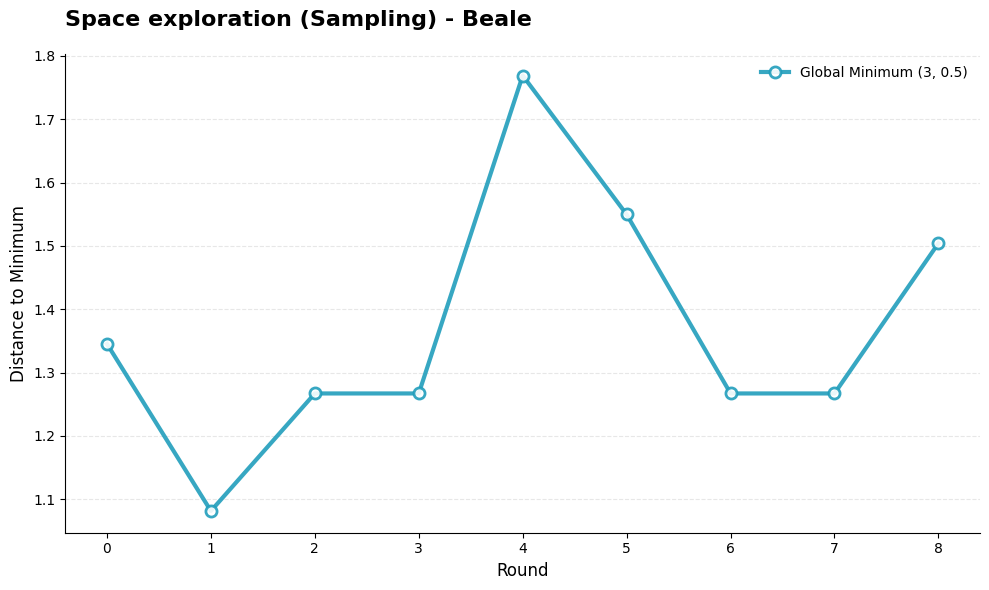

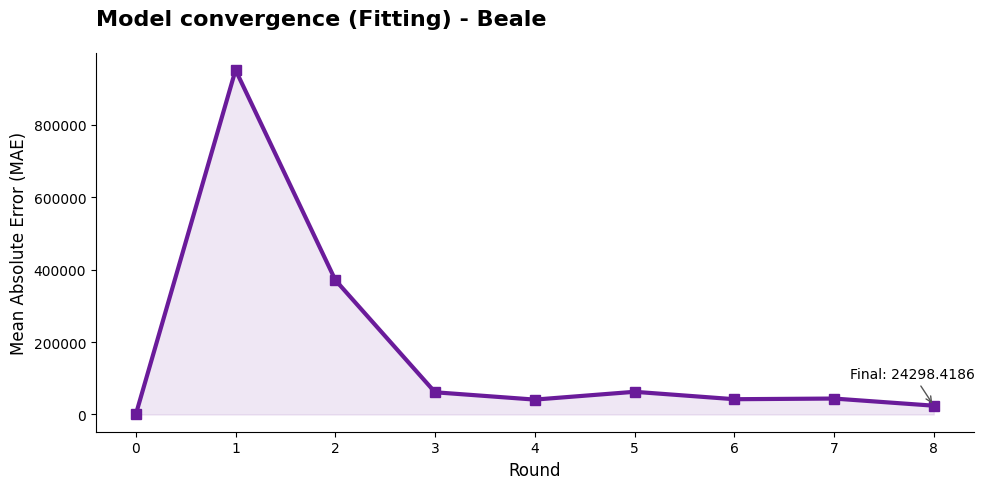

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- CÀRREGA DE DADES ---
folder_path = r"C:\Users\Usuario\Documents\TFM-MELINA\Beale"
input_consolidat = os.path.join(folder_path, "Summary_Table_Beale.csv")

if os.path.exists(input_consolidat):
    df = pd.read_csv(input_consolidat)
    df['Num_Ronda'] = df['ROUNDS'].str.replace('R', '').astype(int)
    df = df.sort_values('Num_Ronda')

    # --- CONFIGURACIÓ ESTÈTICA ---
    plt.rcParams['font.family'] = 'sans-serif'
    color_sampling = '#219ebc' # Triem només un color per a la línia única
    color_fitting = '#6a1b9a'

    # =========================================================
    # --- PLOT 1: SAMPLING (Sols 1 distància per a Beale) ---
    # =========================================================
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # MODIFICACIÓ AQUÍ: Només una columna i una etiqueta
    ax1.plot(df['Num_Ronda'], df['Distance'], 
             marker='o', markersize=8, markerfacecolor='white', markeredgewidth=2,
             linestyle='-', linewidth=3, color=color_sampling, 
             label='Global Minimum (3, 0.5)', alpha=0.9)

    ax1.set_title('Space exploration (Sampling) - Beale', loc='left', fontsize=16, fontweight='bold', pad=20)
    ax1.set_xticks(df['Num_Ronda'])
    ax1.set_xlabel('Round', fontsize=12)
    ax1.set_ylabel('Distance to Minimum', fontsize=12)
    
    ax1.legend(frameon=False)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.grid(axis='y', linestyle='--', alpha=0.3) # Opcional: una miqueta de graella horitzontal
    
    plt.tight_layout()
    plt.show()

    # =========================================================
    # --- PLOT 2: FITTING (MAE) ---
    # =========================================================
    fig, ax2 = plt.subplots(figsize=(10, 5))
    ax2.fill_between(df['Num_Ronda'], df['MAE'], color=color_fitting, alpha=0.1)
    ax2.plot(df['Num_Ronda'], df['MAE'], marker='s', markersize=7, color=color_fitting, linewidth=3)
    
    ax2.set_title('Model convergence (Fitting) - Beale', loc='left', fontsize=16, fontweight='bold', pad=20)
    ax2.set_xticks(df['Num_Ronda'])
    ax2.set_xlabel('Round', fontsize=12)
    ax2.set_ylabel('Mean Absolute Error (MAE)', fontsize=12)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # Anotació final
    final_mae = df['MAE'].iloc[-1]
    ax2.annotate(f'Final: {final_mae:.4f}', 
                 xy=(df['Num_Ronda'].iloc[-1], final_mae),
                 xytext=(-60, 20), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='#555555'))
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Error: No s'ha trobat {input_consolidat}.")